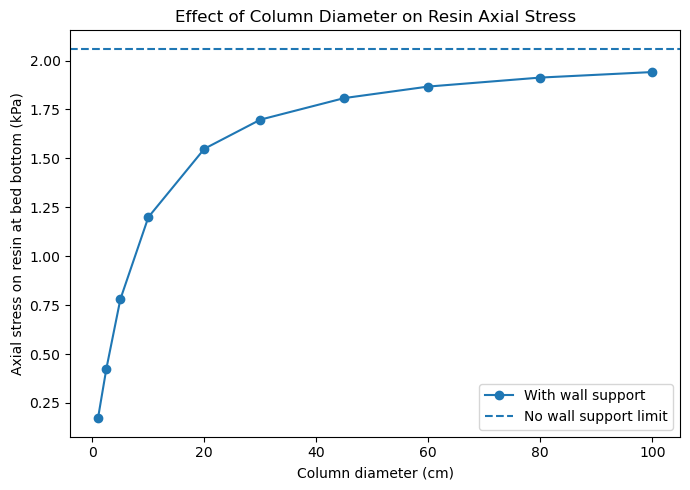

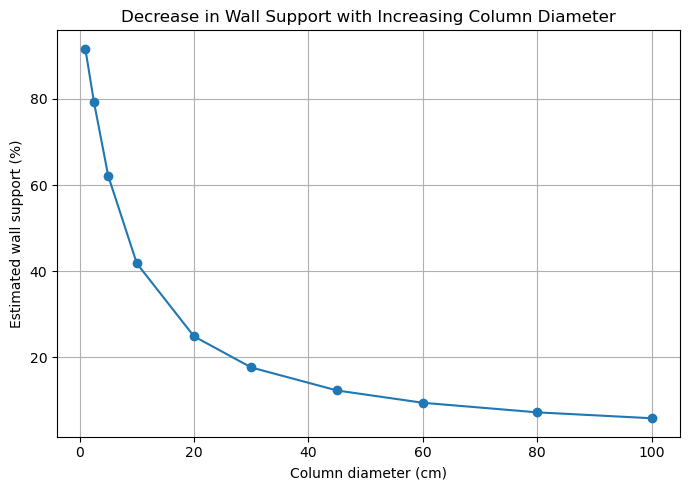

Diameter:   1.0 cm | Resin stress:  0.172 kPa | Wall support:  91.67%
Diameter:   2.5 cm | Resin stress:  0.426 kPa | Wall support:  79.34%
Diameter:   5.0 cm | Resin stress:  0.781 kPa | Wall support:  62.11%
Diameter:  10.0 cm | Resin stress:  1.200 kPa | Wall support:  41.77%
Diameter:  20.0 cm | Resin stress:  1.549 kPa | Wall support:  24.80%
Diameter:  30.0 cm | Resin stress:  1.698 kPa | Wall support:  17.58%
Diameter:  45.0 cm | Resin stress:  1.808 kPa | Wall support:  12.22%
Diameter:  60.0 cm | Resin stress:  1.867 kPa | Wall support:   9.37%
Diameter:  80.0 cm | Resin stress:  1.913 kPa | Wall support:   7.14%
Diameter: 100.0 cm | Resin stress:  1.941 kPa | Wall support:   5.77%


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# User inputs
# -----------------------------
bed_height = 0.20          # m, 20 cm bed height
rho_bulk = 1050           # kg/m3, approximate wet packed resin bulk density
g = 9.81                  # m/s2
mu_wall = 0.30            # wall-resin friction coefficient
K = 0.50                  # lateral-to-vertical stress ratio

# Column diameters to evaluate
diameters_cm = np.array([1, 2.5, 5, 10, 20, 30, 45, 60, 80, 100])
diameters_m = diameters_cm / 100

# -----------------------------
# Janssen model
# -----------------------------
def axial_stress_janssen(D, H, rho, mu, K):
    """
    Returns axial stress at bottom of packed bed.
    D = column diameter, m
    H = bed height, m
    rho = bulk density, kg/m3
    mu = wall friction coefficient
    K = lateral-to-vertical stress ratio
    """
    lam = D / (4 * mu * K)
    sigma = rho * g * lam * (1 - np.exp(-H / lam))
    return sigma

# Stress without wall support: full resin weight carried vertically
sigma_no_wall = rho_bulk * g * bed_height

# Stress with wall support
sigma_wall = np.array([
    axial_stress_janssen(D, bed_height, rho_bulk, mu_wall, K)
    for D in diameters_m
])

# Wall support fraction
wall_support_fraction = 1 - (sigma_wall / sigma_no_wall)

# Convert stress to kPa
sigma_wall_kPa = sigma_wall / 1000
sigma_no_wall_kPa = sigma_no_wall / 1000

# -----------------------------
# Plot 1: Resin axial stress vs diameter
# -----------------------------
plt.figure(figsize=(7, 5))
plt.plot(diameters_cm, sigma_wall_kPa, marker='o', label='With wall support')
plt.axhline(sigma_no_wall_kPa, linestyle='--', label='No wall support limit')
plt.xlabel('Column diameter (cm)')
plt.ylabel('Axial stress on resin at bed bottom (kPa)')
plt.title('Effect of Column Diameter on Resin Axial Stress')
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Wall support fraction vs diameter
# -----------------------------
plt.figure(figsize=(7, 5))
plt.plot(diameters_cm, wall_support_fraction * 100, marker='o')
plt.xlabel('Column diameter (cm)')
plt.ylabel('Estimated wall support (%)')
plt.title('Decrease in Wall Support with Increasing Column Diameter')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Print results
# -----------------------------
for D, stress, support in zip(diameters_cm, sigma_wall_kPa, wall_support_fraction * 100):
    print(f"Diameter: {D:5.1f} cm | Resin stress: {stress:6.3f} kPa | Wall support: {support:6.2f}%")

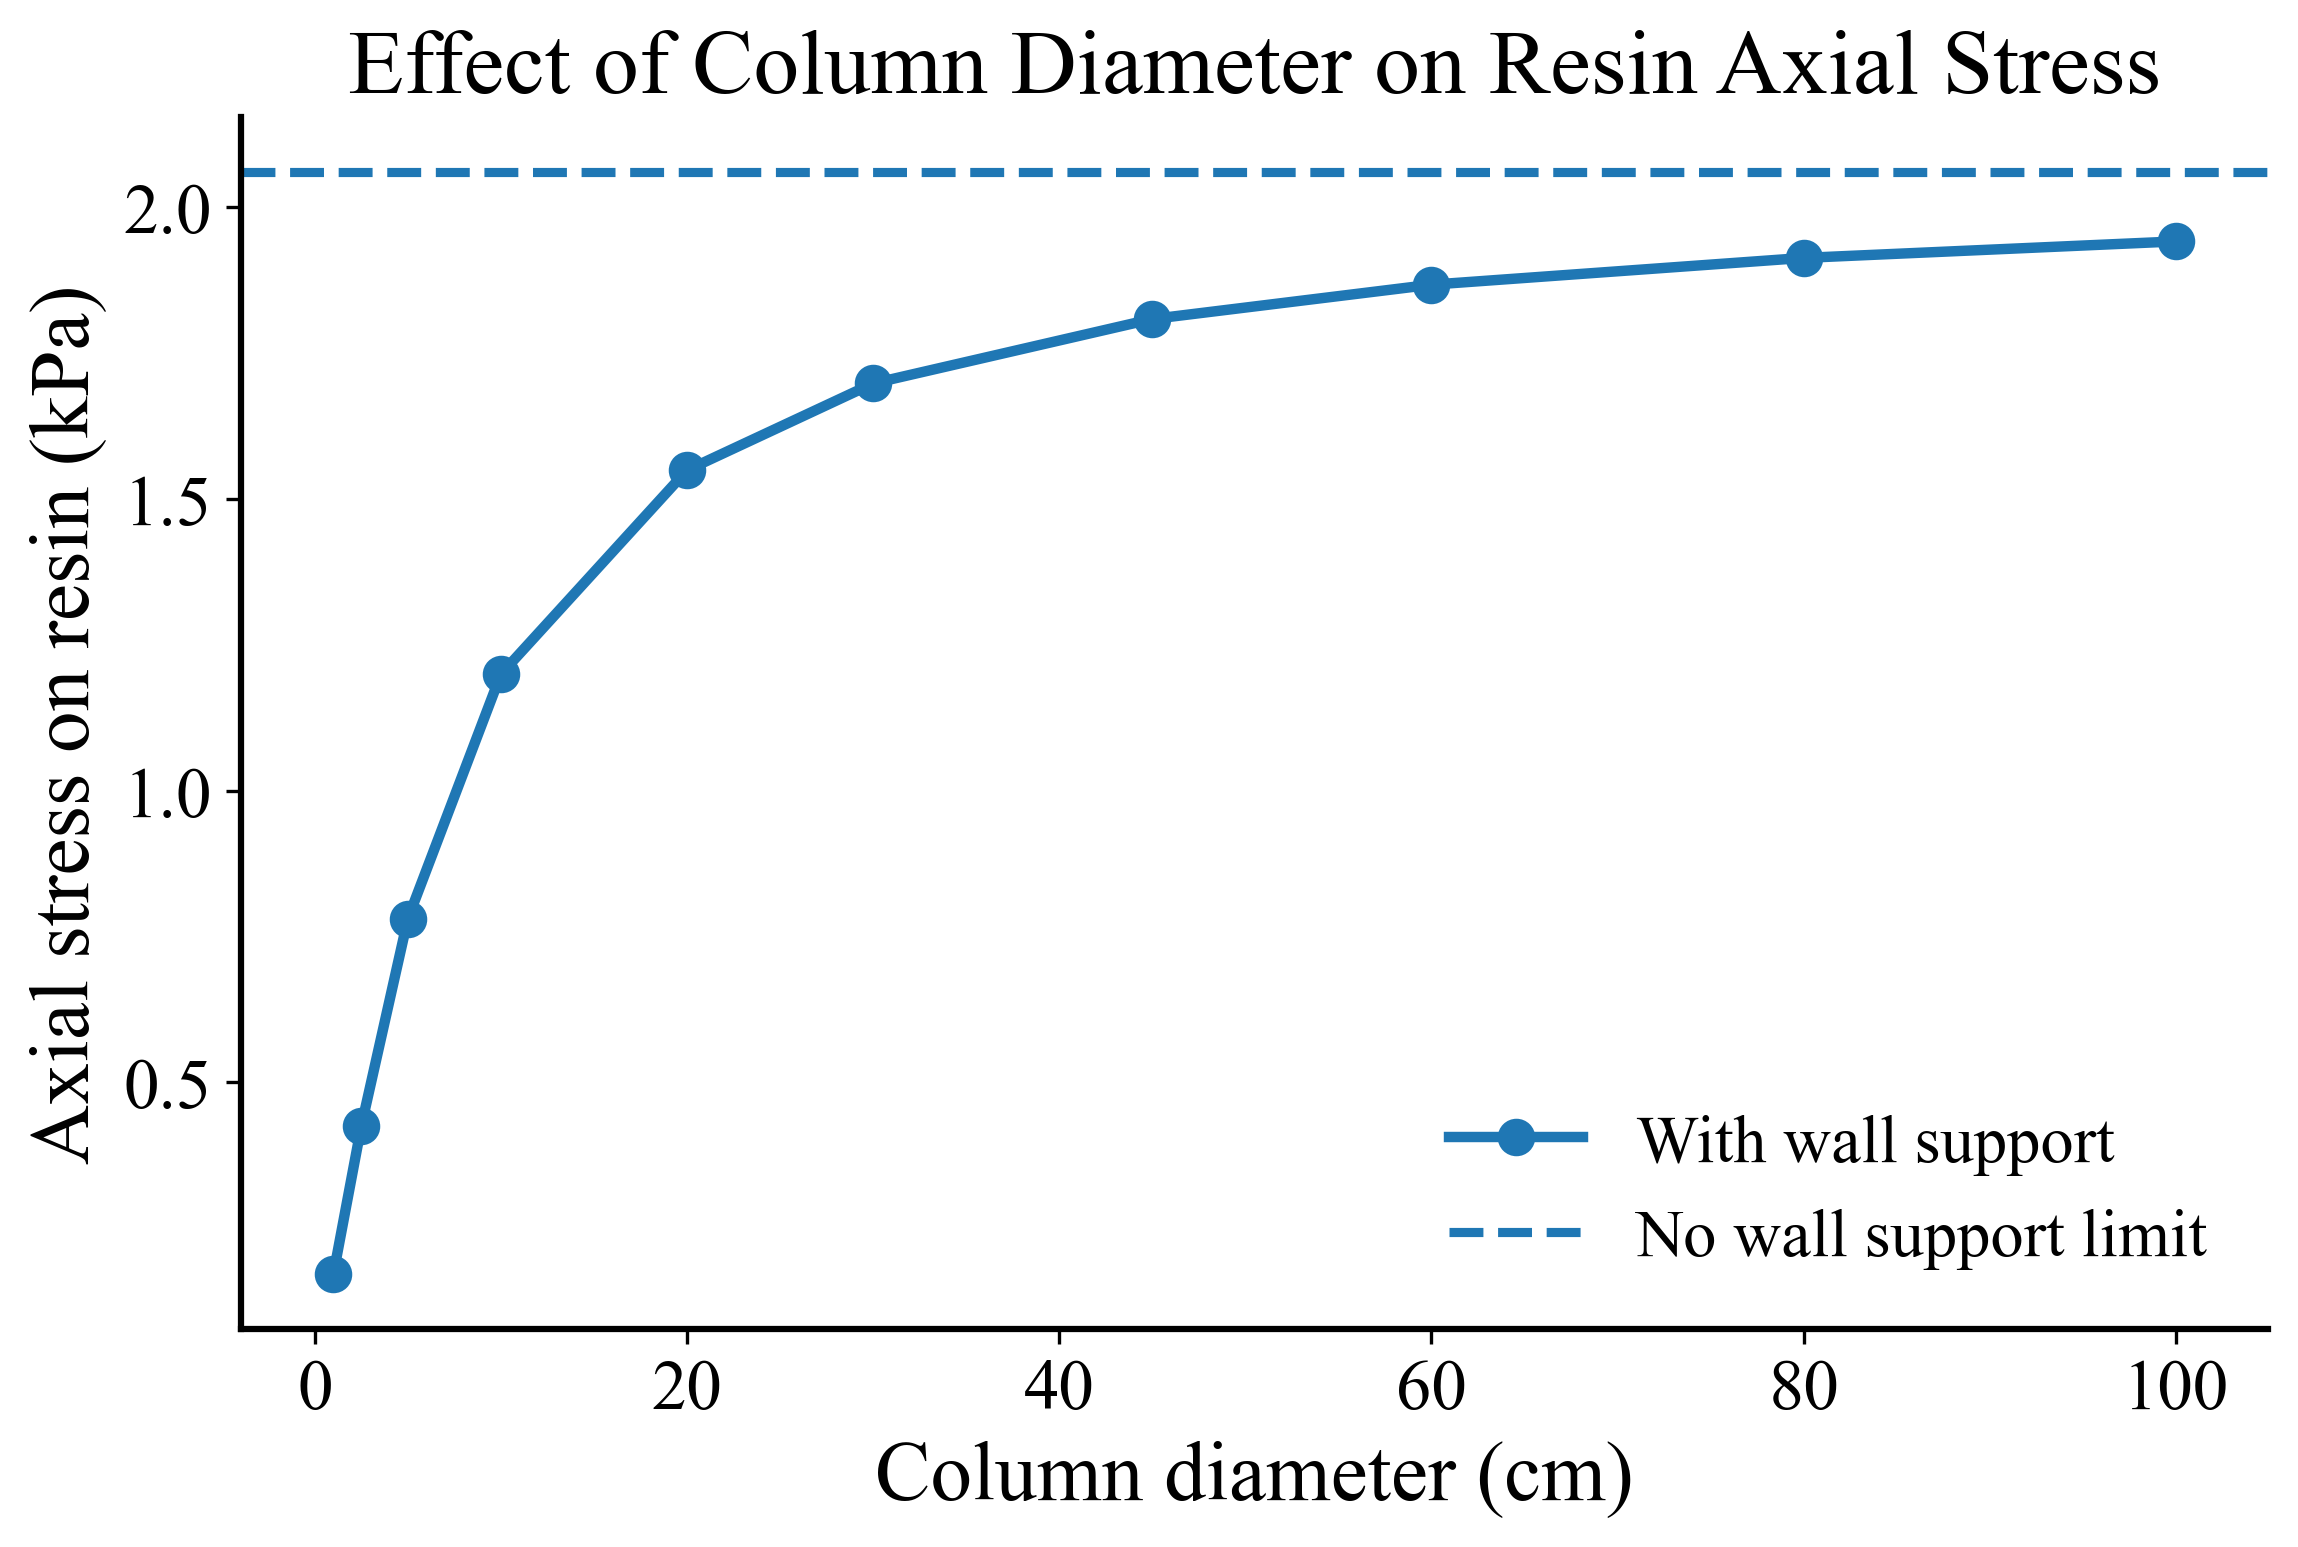

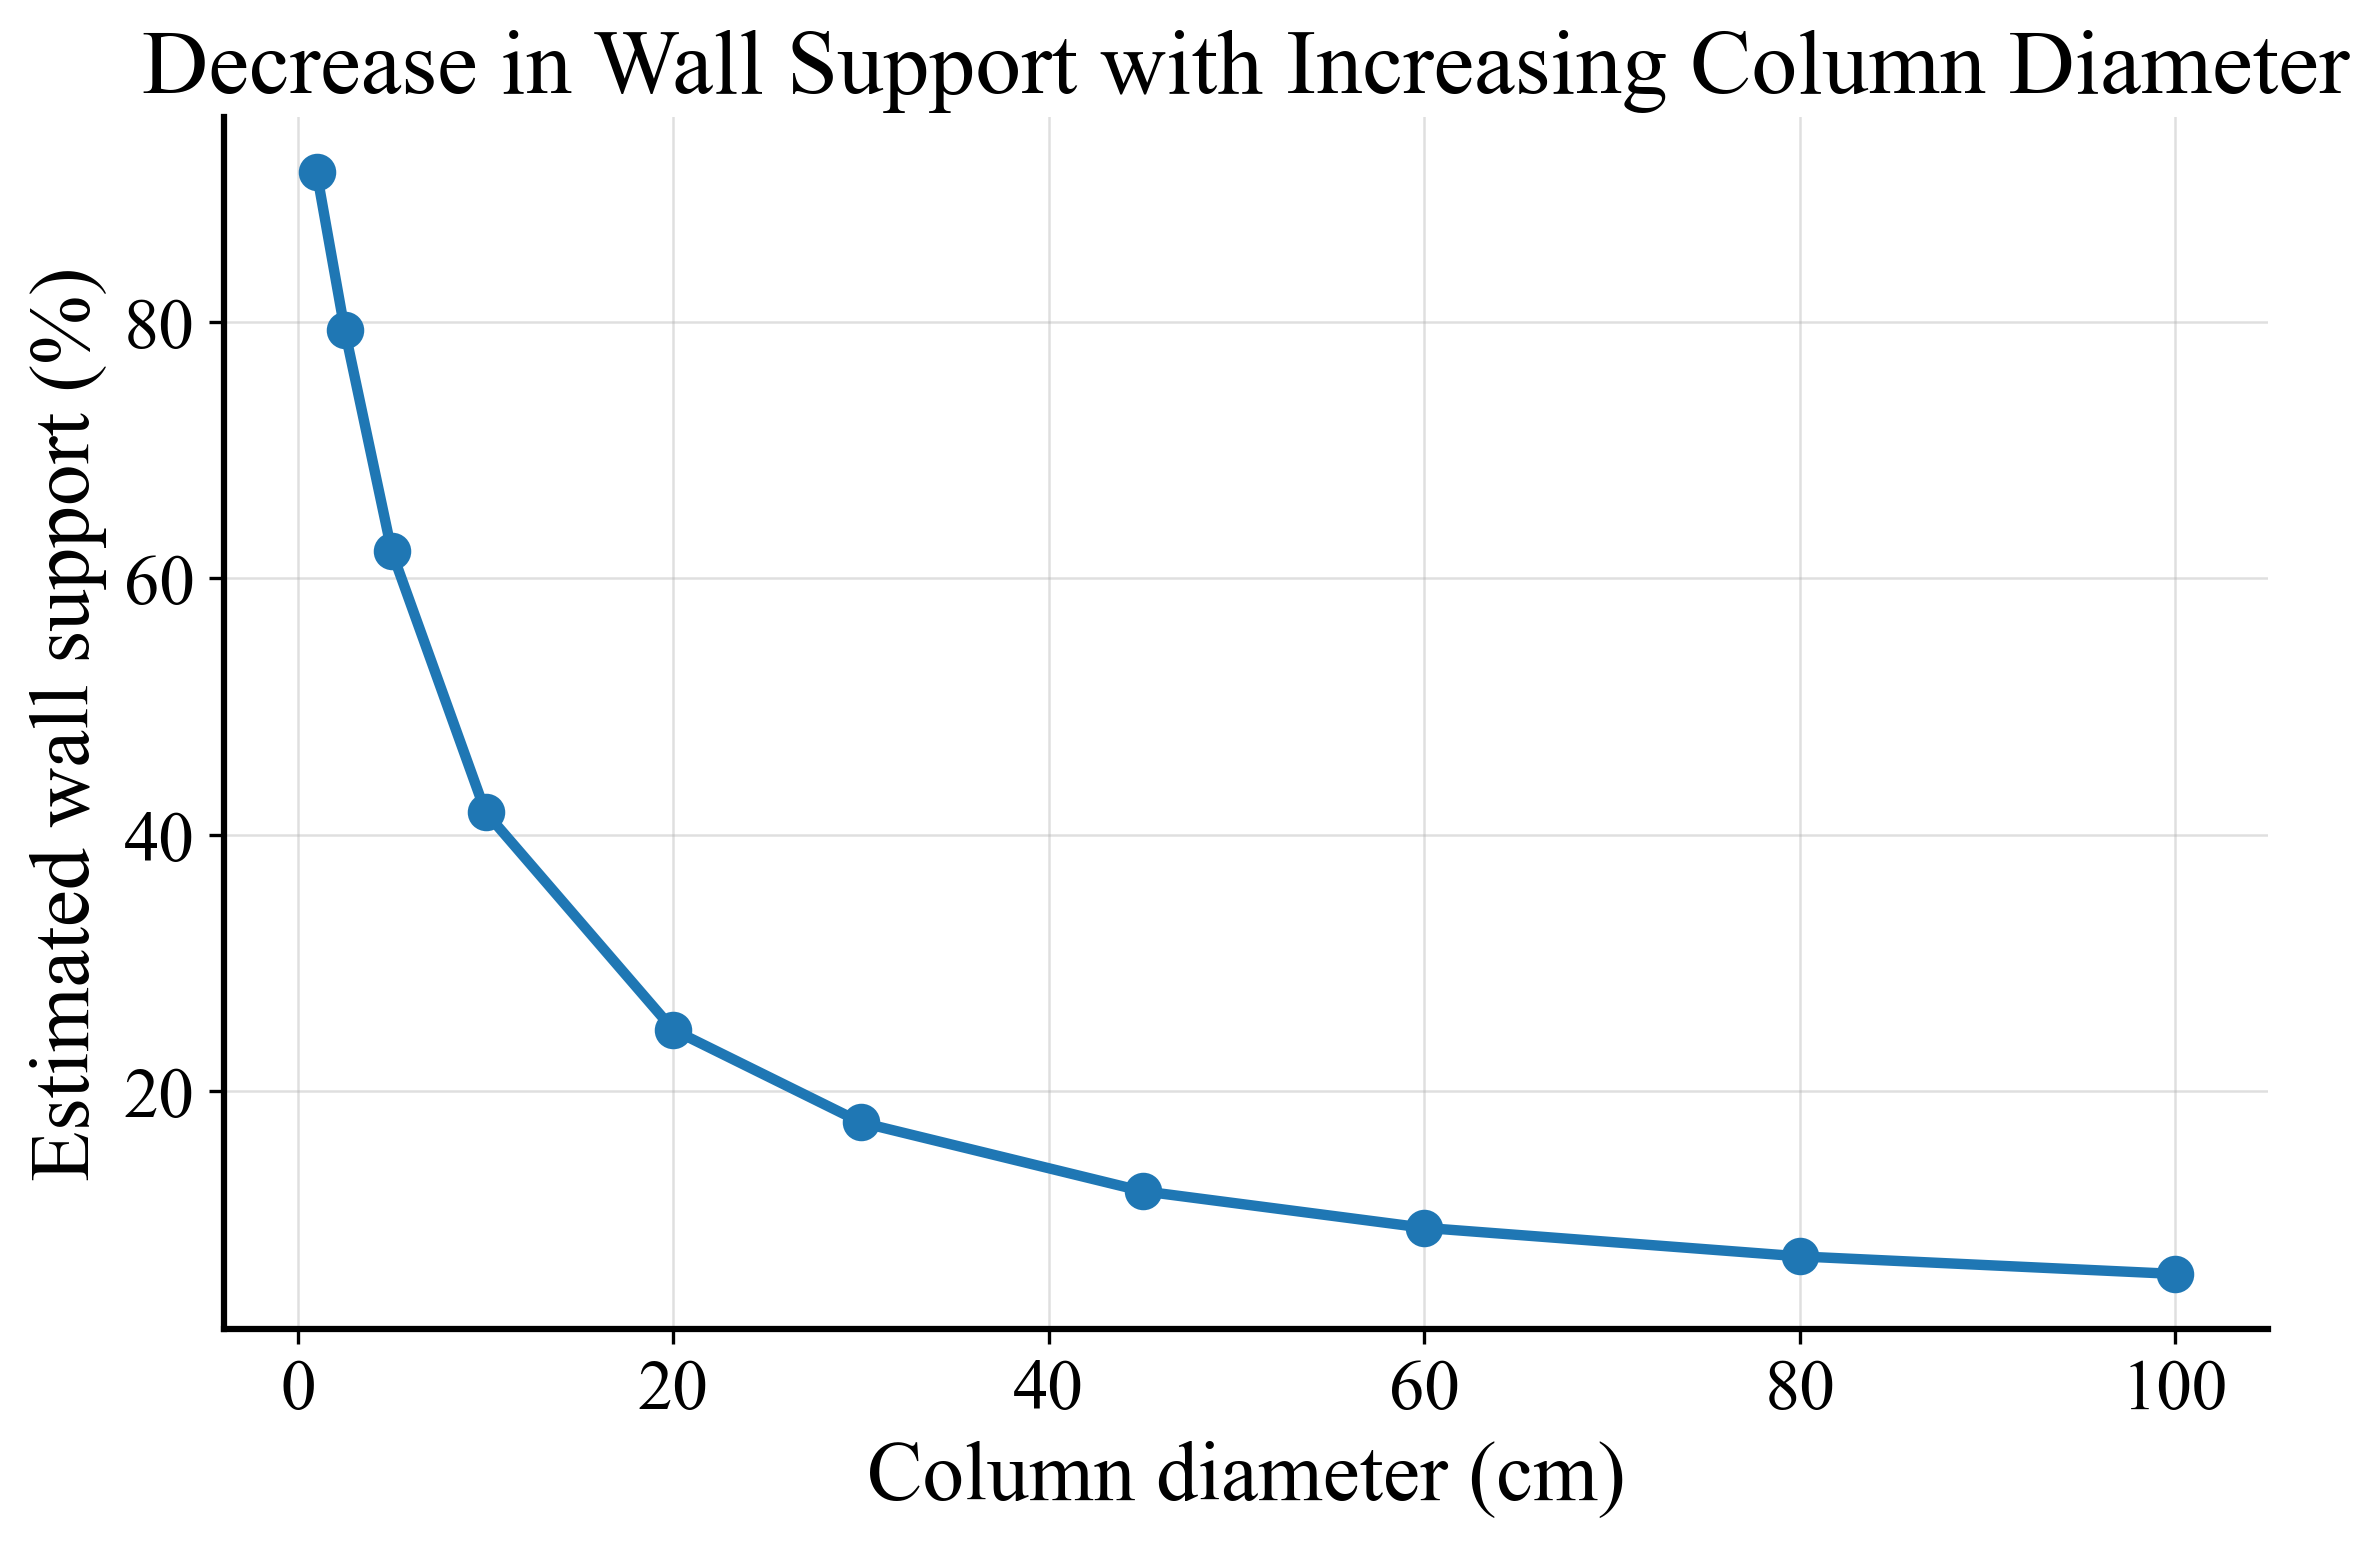

Diameter:   1.0 cm | Resin stress:  0.172 kPa | Wall support:  91.67%
Diameter:   2.5 cm | Resin stress:  0.426 kPa | Wall support:  79.34%
Diameter:   5.0 cm | Resin stress:  0.781 kPa | Wall support:  62.11%
Diameter:  10.0 cm | Resin stress:  1.200 kPa | Wall support:  41.77%
Diameter:  20.0 cm | Resin stress:  1.549 kPa | Wall support:  24.80%
Diameter:  30.0 cm | Resin stress:  1.698 kPa | Wall support:  17.58%
Diameter:  45.0 cm | Resin stress:  1.808 kPa | Wall support:  12.22%
Diameter:  60.0 cm | Resin stress:  1.867 kPa | Wall support:   9.37%
Diameter:  80.0 cm | Resin stress:  1.913 kPa | Wall support:   7.14%
Diameter: 100.0 cm | Resin stress:  1.941 kPa | Wall support:   5.77%


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Global plot style for PPT
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 18
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 22
plt.rcParams["xtick.labelsize"] = 17
plt.rcParams["ytick.labelsize"] = 17
plt.rcParams["legend.fontsize"] = 16
plt.rcParams["axes.linewidth"] = 1.5

# -----------------------------
# User inputs
# -----------------------------
bed_height = 0.20          # m
rho_bulk = 1050           # kg/m3
g = 9.81                  # m/s2
mu_wall = 0.30
K = 0.50

diameters_cm = np.array([1, 2.5, 5, 10, 20, 30, 45, 60, 80, 100])
diameters_m = diameters_cm / 100

# -----------------------------
# Janssen model
# -----------------------------
def axial_stress_janssen(D, H, rho, mu, K):
    lam = D / (4 * mu * K)
    sigma = rho * g * lam * (1 - np.exp(-H / lam))
    return sigma

sigma_no_wall = rho_bulk * g * bed_height

sigma_wall = np.array([
    axial_stress_janssen(D, bed_height, rho_bulk, mu_wall, K)
    for D in diameters_m
])

wall_support_fraction = 1 - (sigma_wall / sigma_no_wall)

sigma_wall_kPa = sigma_wall / 1000
sigma_no_wall_kPa = sigma_no_wall / 1000

# -----------------------------
# Plot 1: Resin axial stress vs diameter
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=300)

ax.plot(
    diameters_cm,
    sigma_wall_kPa,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label="With wall support"
)

ax.axhline(
    sigma_no_wall_kPa,
    linestyle="--",
    linewidth=2.2,
    label="No wall support limit"
)

ax.set_xlabel("Column diameter (cm)")
ax.set_ylabel("Axial stress on resin (kPa)")
ax.set_title("Effect of Column Diameter on Resin Axial Stress")

#ax.grid(True, linewidth=0.6, alpha=0.4)
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("resin_axial_stress_vs_diameter.png", dpi=600, bbox_inches="tight")
plt.savefig("resin_axial_stress_vs_diameter.svg", bbox_inches="tight")
plt.show()

# -----------------------------
# Plot 2: Wall support fraction vs diameter
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=300)

ax.plot(
    diameters_cm,
    wall_support_fraction * 100,
    marker="o",
    markersize=8,
    linewidth=2.5
)

ax.set_xlabel("Column diameter (cm)")
ax.set_ylabel("Estimated wall support (%)")
ax.set_title("Decrease in Wall Support with Increasing Column Diameter")

ax.grid(True, linewidth=0.6, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("wall_support_vs_diameter.png", dpi=600, bbox_inches="tight")
plt.savefig("wall_support_vs_diameter.svg", bbox_inches="tight")
plt.show()

# -----------------------------
# Print calculated values
# -----------------------------
for D, stress, support in zip(diameters_cm, sigma_wall_kPa, wall_support_fraction * 100):
    print(f"Diameter: {D:5.1f} cm | Resin stress: {stress:6.3f} kPa | Wall support: {support:6.2f}%")

# Hypothetical BT Data

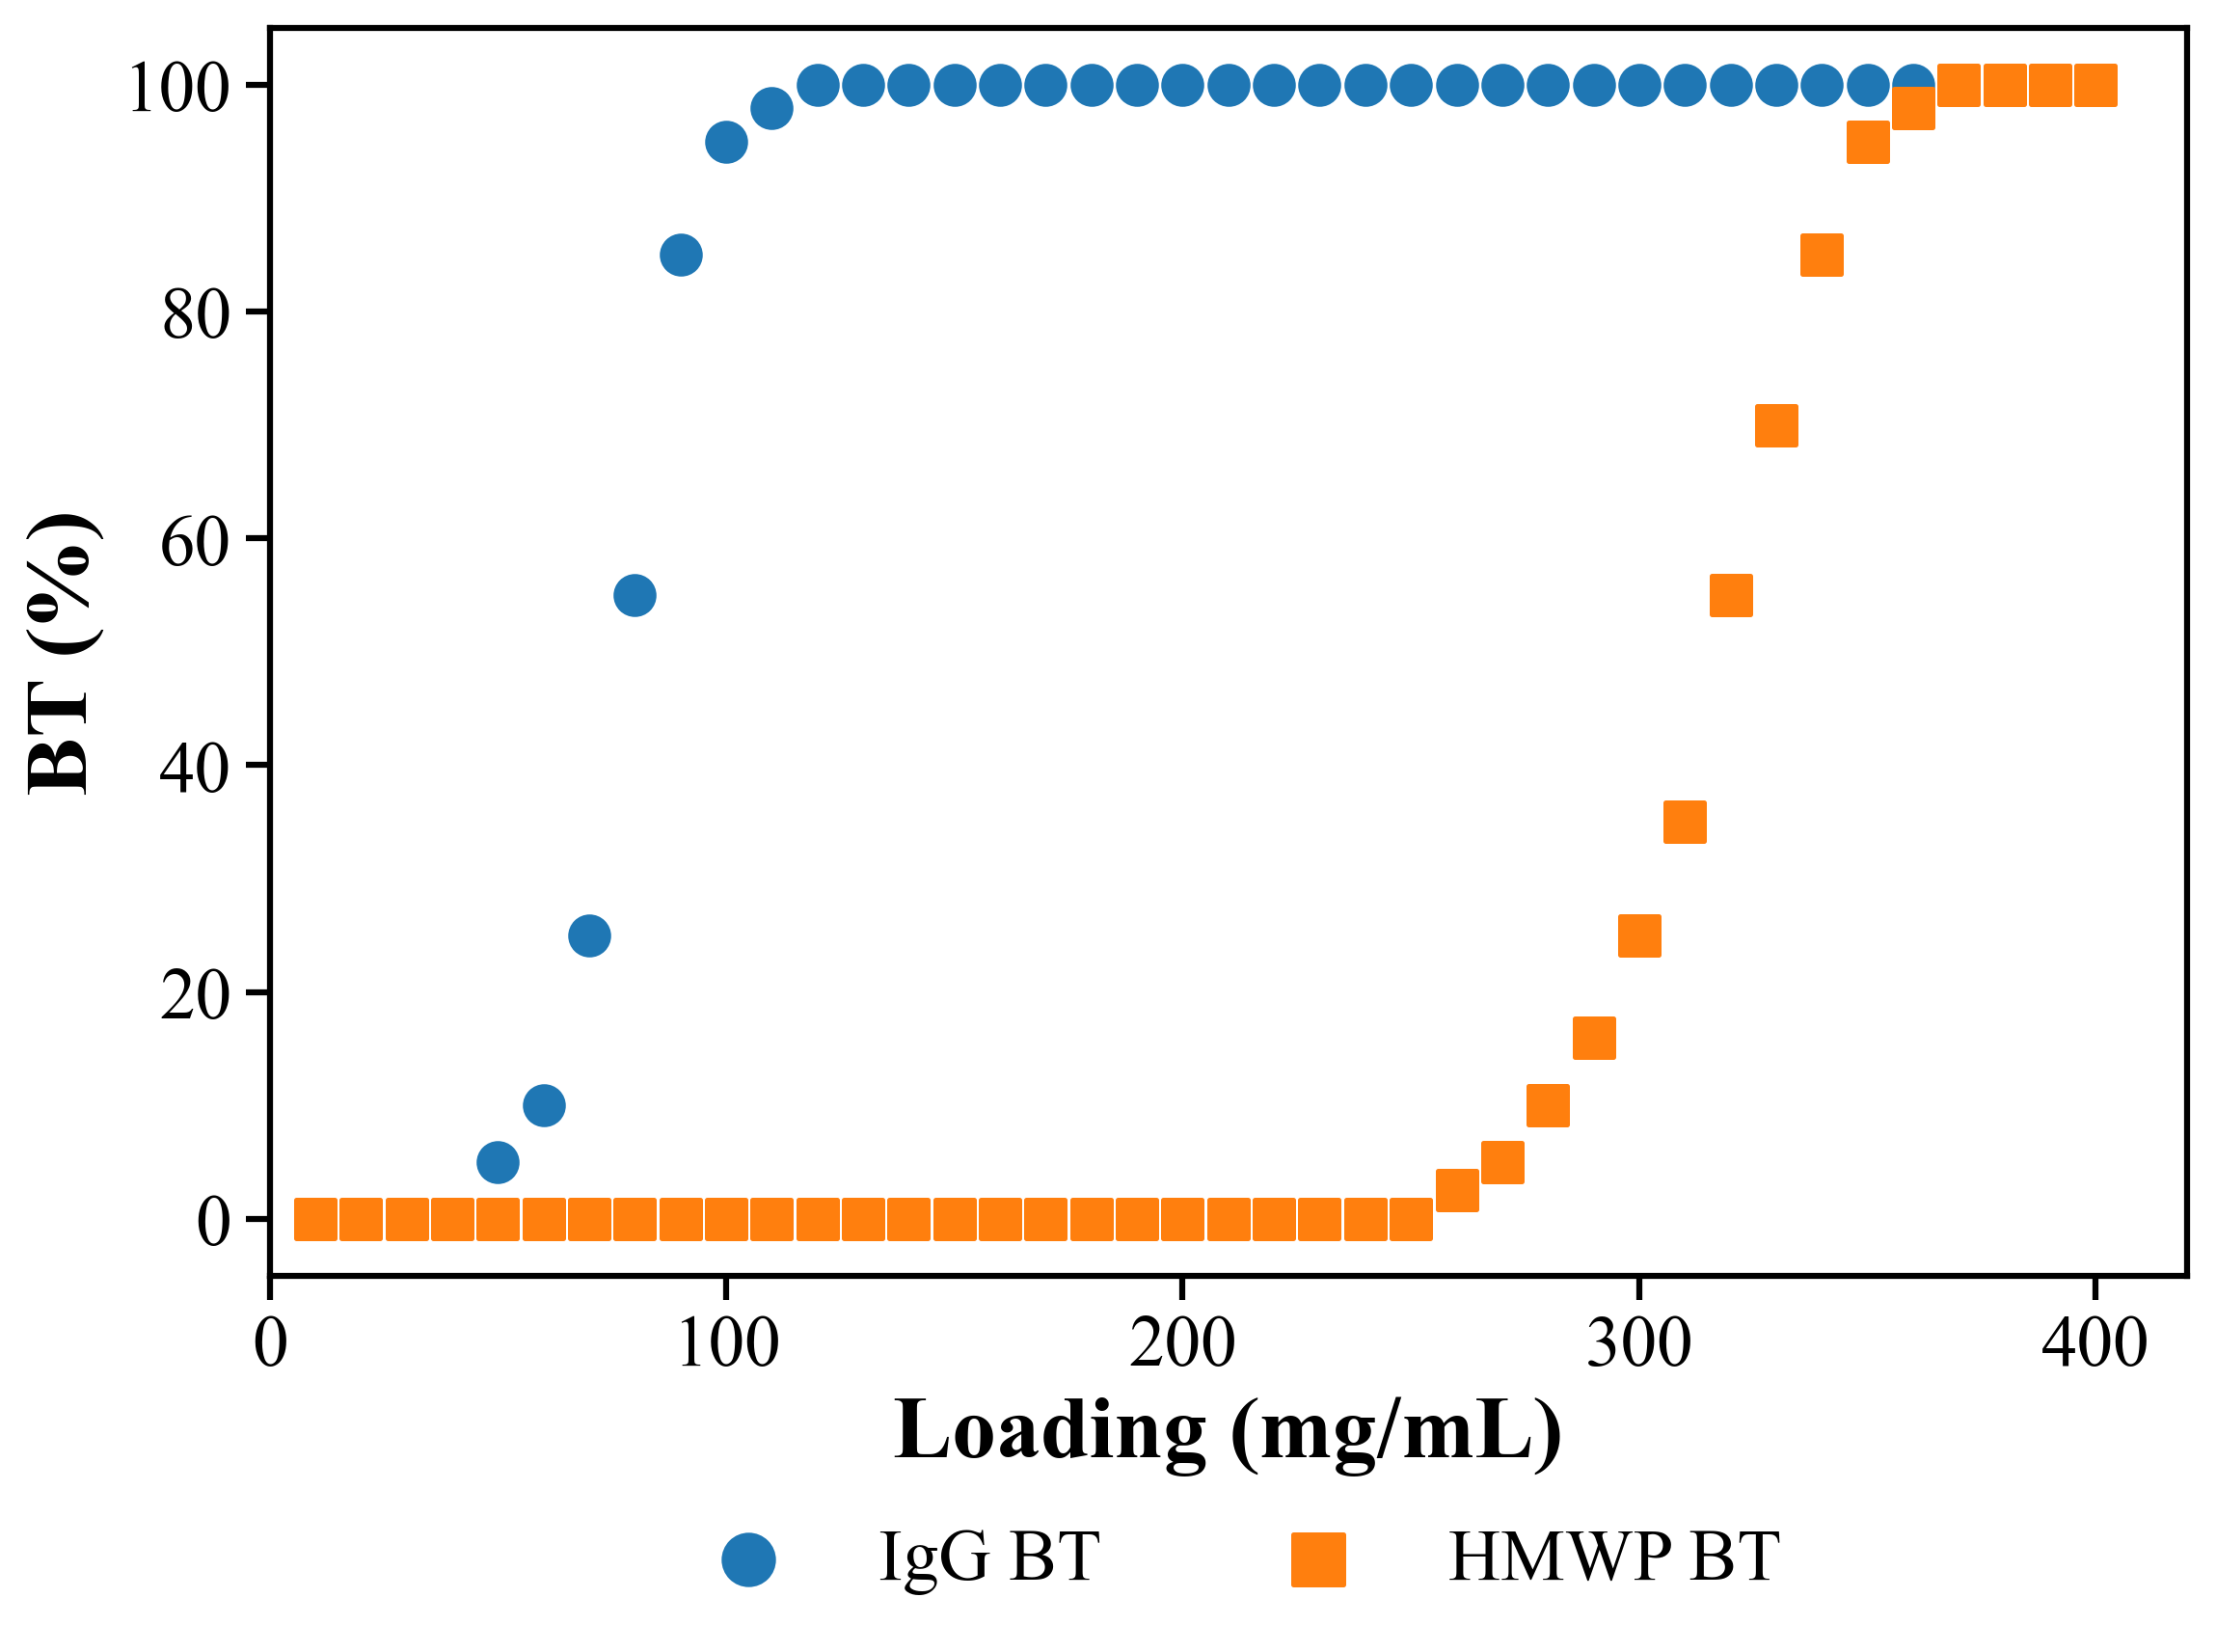

In [13]:
import matplotlib.pyplot as plt

# =========================
# Data
# =========================

loading = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,
           210,220,230,240,250,260,270,280,290,300,310,320,330,340,350,360,370,380,390,400]

product_bt = [0,0,0,0,5,10,25,55,85,95,98,100,100,100,100,100,100,100,100,100,
              100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100]

hmwp_bt = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
           0,0,0,0,0,2.5,5,10,16,25,35,55,70,85,95,98,100,100,100,100]

# =========================
# Figure Formatting
# =========================

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 18

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# =========================
# Scatter Plots
# =========================

ax.scatter(
    loading,
    product_bt,
    s=90,
    marker='o',
    linewidth=1.2,
    label='IgG BT'
)

ax.scatter(
    loading,
    hmwp_bt,
    s=90,
    marker='s',
    linewidth=1.2,
    label='HMWP BT'
)

# =========================
# Axes Labels
# =========================

ax.set_xlabel(
    'Loading (mg/mL)',
    fontsize=22,
    fontweight='bold'
)

ax.set_ylabel(
    'BT (%)',
    fontsize=22,
    fontweight='bold'
)

# =========================
# Axis Limits
# =========================

ax.set_xlim(0, 420)
ax.set_ylim(-5, 105)

# =========================
# Tick Formatting
# =========================

ax.tick_params(
    axis='both',
    which='major',
    labelsize=18,
    width=1.5,
    length=6
)

# =========================
# Remove Grid
# =========================

ax.grid(False)

# =========================
# Thicker Axes
# =========================

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# =========================
# Legend at Bottom
# =========================

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    fontsize=18,
    frameon=False,
    markerscale=1.3
)

# =========================
# Layout
# =========================

plt.subplots_adjust(bottom=0.22)
plt.tight_layout()

# =========================
# Save Figures
# =========================

plt.savefig(
    'CHT_BT_scatter_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'CHT_BT_scatter_plot.svg',
    bbox_inches='tight'
)

plt.show()